# Initial setups

mount google drive and authenticate to access files

In [1]:
#connect to runtime GPU
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


check the currect directory content

In [5]:
! ls
%cd ML-CWs

 ADNI_Tadpole_data_tutorial.xlsx		    ML-TutorialsCW2.ipynb
'Copy of ML-TutorialsCW2.ipynb'			    ML-TutorialsCW.ipynb
 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv   Tutorial_3_data.csv
[Errno 2] No such file or directory: 'ML-CWs'
/content/gdrive/MyDrive/Collaborate /ML-CWs


change directory to specific dir

In [2]:
%cd gdrive/MyDrive/'Collaborate '

/content/gdrive/MyDrive/Collaborate 


install any package if missing

In [ ]:
#! pip install <desired-python-library>

check the access of any file

# Tutorial: 9 convolutional network 
 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F


In [7]:
imdb = torch.load('charsdb.pth')
imdb['sets'].shape

torch.Size([29094])

In [9]:
from torch.utils.data import Dataset, DataLoader

import torchvision

torch.Size([770, 1, 32, 32])


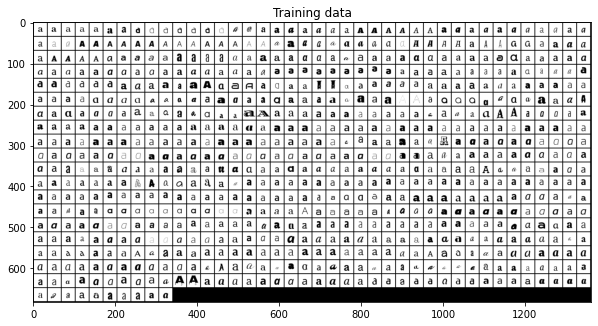

In [10]:
########################################################################################################################
## Making a grid plot of the training data for 'a'
########################################################################################################################

plt.figure(1,figsize=(10,10))
plt.clf()
plt.title('Training data')
sel=(imdb['sets']==0) & (imdb['labels']==0)

images_sel=(imdb['images'][sel,:,:,:])
print(images_sel.size())

tensor_grid=torchvision.utils.make_grid(images_sel,nrow=40)
image_grid=tensor_grid.permute(1,2,0)
plt.imshow(image_grid)

tensor([-0.3667], grad_fn=<AddBackward0>)


<Figure size 360x360 with 0 Axes>

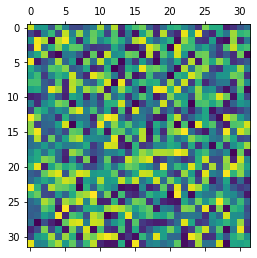

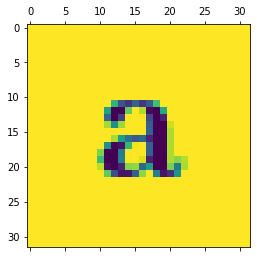

In [11]:
########################################################################################################################
## Build a fully connected layer with 32x32 input and 1 output
########################################################################################################################

# Initialize the layer and extract the weights
model=nn.Linear(32*32,1)
weight=model.weight

## Display the weights as an image
weight=weight.reshape(32,32).detach().numpy()
plt.figure(2,figsize=(5,5))
plt.matshow(weight);

# Transform a sample image into a flat array 32*32x1 
sample_image=images_sel[0,:,:,:].squeeze()

plt.figure(2,figsize=(5,5))
plt.matshow(sample_image);

image_flatten=torch.flatten(sample_image)

# Apply the fully connected layer to the image
prediction=model(image_flatten)
print(prediction)

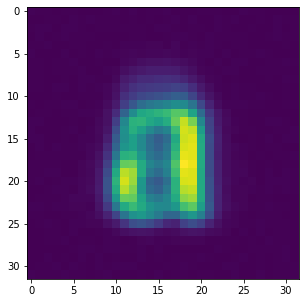

In [12]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Prepare all images to be processed by the fully connected neuron
image_view=torch.flatten(images_sel,1,3)
label=0
#print(image_view.size())

# Compute the output of all 'a'
prediction=model(image_view);

# Compute the difference between prediction and true label 
loss=(prediction-label).sum()

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Show the updated weights
weight=model.weight.reshape(32,32).detach().numpy()

plt.figure(2,figsize=(5,5))
plt.imshow(weight);

torch.Size([5, 1, 28, 28])

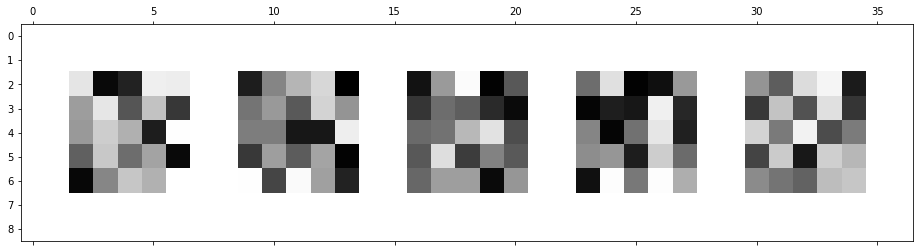

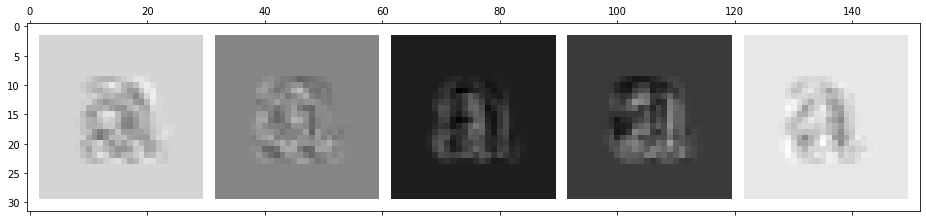

In [13]:
########################################################################################################################
## Build a convolutional layer with 5 filters, 5x5
########################################################################################################################

# Initialize the layer
model=nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)

#Extract and plot the weights
weight=model.weight.detach()

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
image_filtered=model(sample_image)
image_filtered=image_filtered.permute(1,0,2,3)

# plot resulting feature maps
tensor_grid=torchvision.utils.make_grid(image_filtered,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid)

image_filtered.size()

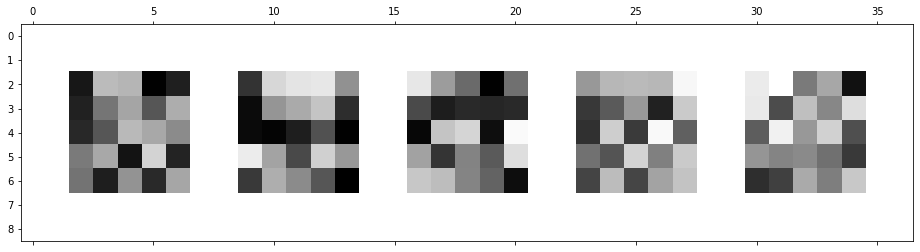

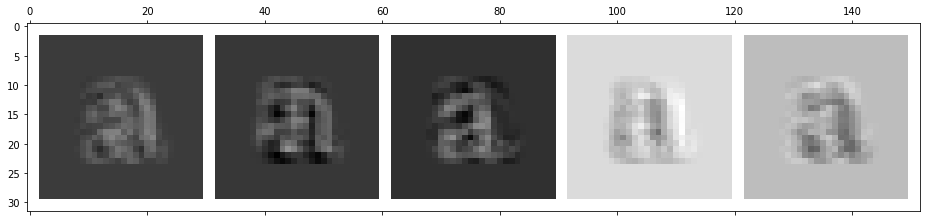

In [14]:
########################################################################################################################
## Build a small convolutional network
########################################################################################################################

# Define the model
class CNN_model(nn.Module):
    def __init__(self):
        super(CNN_model, self).__init__()
        
        self.layer_1 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)
        self.layer_2 = nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, groups=5)
        self.layer_3=nn.Flatten(1,3)
        self.layer_4=nn.Linear(24*24*5,26)
        
    def forward(self,x):
        x1 = self.layer_1(x)
        x = nn.ReLU()(x1)
        x2 = self.layer_2(x)
        x = nn.ReLU()(x2)
        x = self.layer_3(x)
        x = nn.ReLU()(x)
        x = self.layer_4(x)
        
        return x, x1, x2

# Initialize the model
model=CNN_model()

# Display the filters of layer 1
weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH and apply the network to the image
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
x,x1,x2=model(sample_image)

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

using Kbest

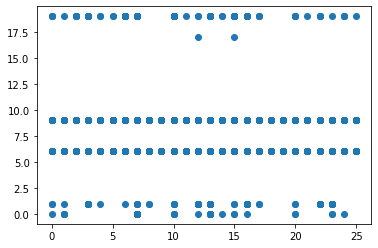

In [15]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

loss_fun=nn.CrossEntropyLoss()

labels=imdb['labels']
inputs=imdb['images']

# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Compute the difference between prediction and true label 
#loss=((preds-labels)**2).sum()
loss=loss_fun(prediction,labels)

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Visializing the predictions
plt.plot(labels,preds.detach().numpy(),'o')

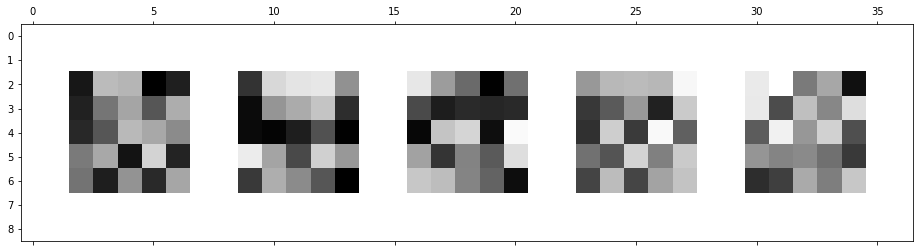

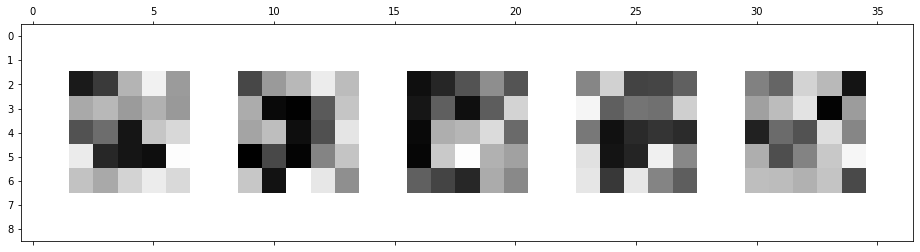

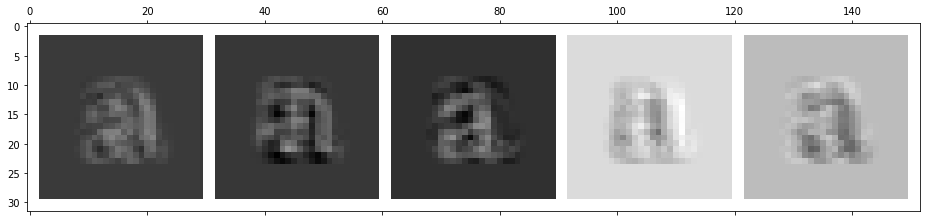

In [16]:
########################################################################################################################
## Visualizing updated weights
########################################################################################################################

weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

weight=model.layer_2.weight
tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

x,x1,x2=model(images_sel[0,:,:,:].unsqueeze(0))

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

In [18]:
from sklearn.model_selection import train_test_split


In [19]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

# Splitting data into training and validation
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    imdb['images'],imdb['labels'],
    test_size=0.2, 
    random_state=42,
)

#Defining the Dataset 
class Char_Dataset(Dataset):
    def __init__(self,data,target,train:bool = True, transforms=None):
        self.data=data
        self.target=target
        self.train=train
        self.transforms=transforms
        
    def __getitem__(self,index):
        
        x=self.data[index,]
        
        if(self.train):
            if(self.transforms):
                x=self.transforms(x)
                
        
        if(self.train):
            # During training, for each image the Dataset returns
            #  - an image x
            #  - the true class y:  
            y=self.target[index,]
            return x,y
        else:
            # During testing, only the image is returned
            return x
        
    def __len__(self):
        return len(self.target)
    
# Initializion datasets and dataloaders
batch_size = 500

train_dataset=Char_Dataset(
    data=Xtrain,
    target=Ytrain,
    train=True,
    transforms=None
)

valid_dataset=Char_Dataset(
    data=Xvalid,
    target=Yvalid,
    train=True,
    transforms=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

In [20]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################
datasets={'train':train_dataset,'valid':valid_dataset}
dataloaders={'train':train_loader,'valid':valid_loader}

optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

# if GPU is available, use it, otherwise use CPU
device = torch.device("cuda")

########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

for epoch in range(num_epochs):

    running_loss = 0.0
    running_corrects = 0.0
        
    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels=labels.to(device)

            # Zero out the grads
            optimizer.zero_grad()

            # Forward
            # Track history in train mode
            with torch.set_grad_enabled(phase == 'train'):
                model=model.to(device)
                outputs, x1, x2 = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels.type(torch.LongTensor).to(device))

                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                
                # Statistics
                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss/len(datasets[phase])
        epoch_acc = running_corrects.double()/len(datasets[phase])
        print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

train Loss: 3.2862 Acc: 0.0734
valid Loss: 16.3531 Acc: 0.3616
train Loss: 2.0181 Acc: 0.4560
valid Loss: 10.3097 Acc: 2.1956
train Loss: 1.0164 Acc: 0.7310
valid Loss: 4.6473 Acc: 3.7761
train Loss: 0.5443 Acc: 0.8569
valid Loss: 2.6694 Acc: 4.3057
train Loss: 0.4316 Acc: 0.8872
valid Loss: 2.2377 Acc: 4.4319
train Loss: 0.5508 Acc: 0.8510
valid Loss: 2.6925 Acc: 4.2848
train Loss: 0.4114 Acc: 0.8907
valid Loss: 2.1518 Acc: 4.4496
train Loss: 0.3575 Acc: 0.9048
valid Loss: 1.8688 Acc: 4.5090
train Loss: 0.3126 Acc: 0.9154
valid Loss: 1.7664 Acc: 4.5365
train Loss: 0.3196 Acc: 0.9133
valid Loss: 1.7787 Acc: 4.5375


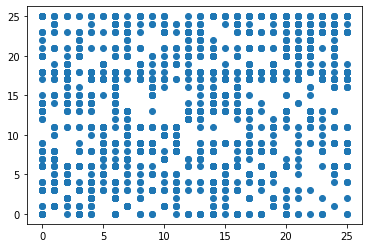

In [21]:
labels=imdb['labels']
inputs=imdb['images']

model=model.to(torch.device("cpu"))
# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Visualizing the predictions
plt.plot(labels,preds.detach().numpy(),'o')

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

In [ ]:
LR = LogisticRegression(penalty='none', class_weight='none', max_iter=10000, solver='saga' )


In [ ]:
sfs = SequentialFeatureSelector(LR, n_features_to_select=10, direction='forward')

In [ ]:
sfs.fit(x_train, y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


SequentialFeatureSelector(estimator=LogisticRegression(class_weight='none',
                                                       max_iter=10000,
                                                       penalty='none',
                                                       solver='saga'),
                          n_features_to_select=10)

In [ ]:
col = sfs.get_support(indices=True)
selected_column = x_train.iloc[:,col].columns.tolist()
print(selected_column)

['AGE', 'GENDER', 'EDUCATION', 'ApoE4', 'CDRSB', 'MMSE', 'RAVLT_forgetting', 'FAQ', 'Accumbens area left volume', '1terior cingulate gyrus right volume']


In [ ]:
kf = KFold(n_splits = 10, shuffle = True)
data_mat = np.array(x_data)
label_mat = np.array(y_target)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  LR = LogisticRegression(penalty='none', class_weight='none', max_iter=10000, solver='saga' )
  sfs = SequentialFeatureSelector(LR, n_features_to_select=5, direction='forward')
  sfs.fit(train_data, train_label)
  col = sfs.get_support(indices=True)
  print(col)


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means 

[ 0  1  3  6 51]


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means 